In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
iris=datasets.load_iris()
X=iris.data
y=iris.target

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [5]:
mlp=MLPClassifier(hidden_layer_sizes=(10,10),activation='relu',solver='adam',max_iter=1000,random_state=42)
mlp.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

In [6]:
y_pred=mlp.predict(X_test)

In [16]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("F1:",f1_score(y_test, y_pred, average='weighted'))
print("Precision:",precision_score(y_test, y_pred, average='weighted', zero_division=1))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.9666666666666667
F1: 0.9664109121909632
Precision: 0.9694444444444444

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



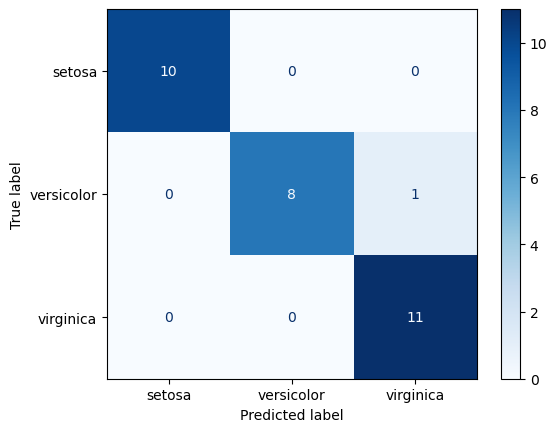

In [17]:
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)

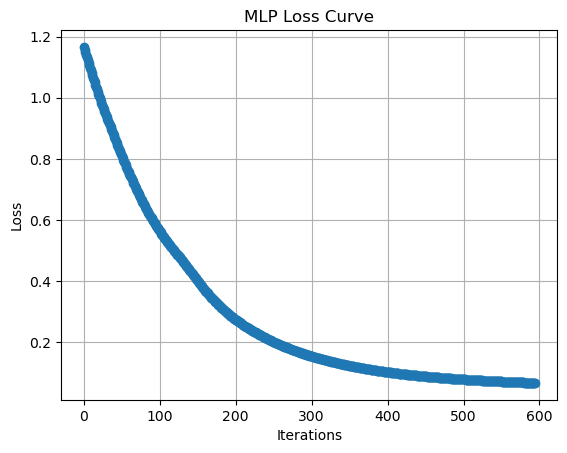

In [19]:
plt.plot(mlp.loss_curve_, marker='o')
plt.title("MLP Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid()